In [59]:
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

# Autoencoders
Un autoencoder aprende a comprimir los datos en una representacion de menor dimension para posteriormente reconstruirlos a su forma original o aproximada.<br>
Para este ejercicio necesitamos instalar tensorflow el cual lo hemos instalado en otro cuaderno anteriormente

In [60]:
digitos = load_digits()
digitos #Este es un dataset el cual es basicamente un diccionario que contiene un mapa de bits de 8x8

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [61]:
digitos["data"][0].reshape(8,8) #si llamamos a la primera posicion del dataset con un reshape de 8x8 nos da lo siguiente

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

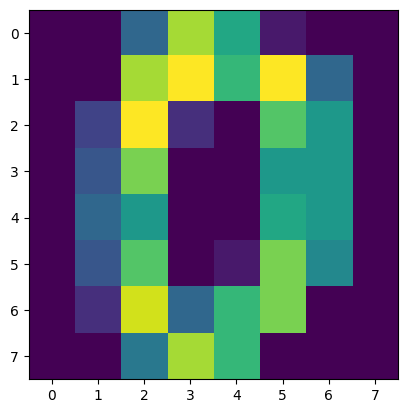

In [62]:
plt.imshow(digitos["data"][0].reshape(8,8)); #si pintamos esos datos nos daría el numero 0 pintado

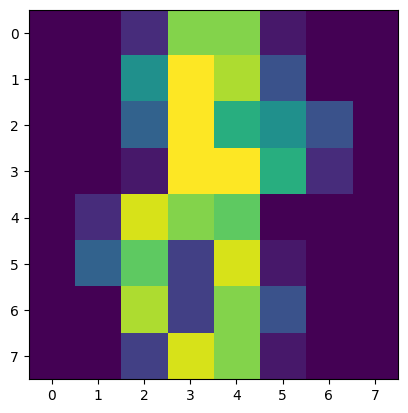

In [63]:
plt.imshow(digitos.images[158]); #otra forma de mandar a pintar los datos, esta vez es el 4 pintado

In [64]:
X = digitos.data

In [65]:
X = X / 16.0 #Esto es para normalizar los datos y que todos partan de la misma salida. Por qué /16? pues porque los valores de que tan pintado esta el bit va del 0 al 16
X #Este paso se puede no hacer pero esto ayuda a que el entrenamiento sea mucho mas rápido. Es para ayudar al algoritmo

array([[0.    , 0.    , 0.3125, ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.625 , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 1.    , 0.5625, 0.    ],
       ...,
       [0.    , 0.    , 0.0625, ..., 0.375 , 0.    , 0.    ],
       [0.    , 0.    , 0.125 , ..., 0.75  , 0.    , 0.    ],
       [0.    , 0.    , 0.625 , ..., 0.75  , 0.0625, 0.    ]],
      shape=(1797, 64))

In [66]:
X_entrena, X_prueba = train_test_split(X, test_size = 0.2, random_state=42); #Con esto decimos que nos deje el 20% en entrenamiento y el 80% restante en prueba

In [67]:
imagen_entrada = Input(shape=(64,)) #Esto es para instalar una capa tensorial, lo que quiere decir que es la forma esperada que queremos que tengan nuestros datos (8x8=64).

### Red neuronal:
##### Codificador
Lo que contiene lo siguiente es una capa densa, significa que contiene muchismos puntos de información conectados entre si.64 puntos de información donde todos se conectan con todos<br>
El primer argumento (32) son el numero de nodos que queremos, los nodos son las neuronas que queremos usar. Si usas muchos nodos puede generar ruido, lo que es perjudicial para el aprendizaje, si usas pocos puede no llegar a entender los patrones, lo que nos daría un modelo simple. En este caso la eleccion de 32, que es la mitad de los 64 datos que tenemos.<br>
El segundo argumento (activation) se refiere a la funcion de activacion que vamos a usar en esta capa, y "relu" es una de las opciones mas comunes por su simplicidad y su eficacia.<br>
El tercer y ultimo argumento (imagen_entrada) son los datos con los que irá trabajando
##### Decodificador
El primer argumento será normalmente el numero de datos del input (64).<br>
El segundo argumento convierte los valores de entrada a la capa en valores entre 0.0 y 1.0
El tercero es la codificación

In [68]:
codificado = Dense(32, activation="relu")(imagen_entrada)

In [69]:
decodificado = Dense(64, activation="sigmoid")(codificado)

In [70]:
autoencoder = Model(imagen_entrada, decodificado)

#### Autoencoder
El metodo complie define como el autoencoder tiene que aprender de los datos: <br>
El primer argumento, optimizer, es el uqe se encarga de ajustar lso pesos del modelo y adam, es uno de los optimizadores mas populares y mas usados pues ajusta la tasa de aprendizaje en la mayoria de los casos sin demasidada configuracion
El segundo, loss, mide que tan bien el modelo realiza su trabajo. binary_crossentropy es una entrada muy util cuando los valores son binarios o van de 0 a 1


In [71]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

##### Entrenamiento
Usamos el mismo conjunto de datos X_entrena tanto como para las entradas como para las salidas esperadas puesto que aqui queremos reconstruir las entradas originales.<br><br>
`epochs` es la cantidad de ciclos que tendra nuestro entrenamiento.<br><br>
`batch_size`, esto es porque durante el entrenamiento los datos se almacenan por lotes y en este caso significa que queremos pasar 64 datos de X_entrena, procesarlos, actualizar su peso y luego coger otros 64 para que el modelo sea más eficiente. Usamos el 64 esta vez.<br><br>
El argumento `shuffle` hace lo esperado, mezcla cada ciclo los datos para que el modelo no aprenda el orden de los datos, si no a saber interpretarlos.<br><br>
`validation_data` coge los datos de X_prueba para usarlos y saber que tan bien se ha entrenado el autoencoder, otra vez queremos saber la mayor exactitud de los datos, por lo que usamos los mismos datos.

In [77]:
autoencoder.fit(X_entrena, X_entrena, epochs=300, batch_size=64, shuffle=True, validation_data=(X_prueba, X_prueba))

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2300 - val_loss: 0.2329
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2301 - val_loss: 0.2329
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2300 - val_loss: 0.2328
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2300 - val_loss: 0.2328
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2300 - val_loss: 0.2328
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2300 - val_loss: 0.2328
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2299 - val_loss: 0.2328
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2299 - val_loss: 0.2328
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2299 - val_loss: 0.2328
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2299 - val_loss: 0.2328
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2299 - val_loss: 0.2327
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


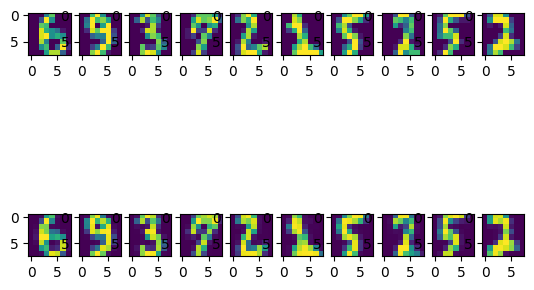

In [80]:
#Comprobación
for i in range(10):
    plt.subplot(2,10, i+1) # 2 filas por 10 columnas, y la posición de cada grafico
    plt.imshow(X_prueba[i].reshape(8,8))
    plt.subplot(2,10, i+11)
    plt.imshow(autoencoder.predict(X_prueba)[i].reshape(8,8))